In [1]:
#data understanding

In [52]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv(r"../data/HAM10000_metadata.csv")
df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [4]:
#checking for duplicated
df[df.duplicated()]

,lesion_id,image_id,dx,dx_type,age,sex,localization


In [5]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
len(df["image_id"].unique())#count 10015
len(df["lesion_id"].unique())#count 7470
len(df["dx_type"].unique())#count 4
len(df["dx"].unique())#count 7
df['sex'].unique() #count 3 [male,female,unknown]
df["localization"].unique()#count 15 (14 + 1(unknown) )

<StringArray>
[          'scalp',             'ear',            'face',            'back',
           'trunk',           'chest', 'upper extremity',         'abdomen',
         'unknown', 'lower extremity',         'genital',            'neck',
            'hand',            'foot',           'acral']
Length: 15, dtype: str

In [7]:
df.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [8]:
img = "../data/all_image"

file = os.listdir(img)

len(file)

10015

In [9]:
df["path"] = "../data/all_image/"+df["image_id"]+".jpg"

In [10]:
# Check if every file in the 'path' column actually exists on disk
df['file_exists'] = df['path'].apply(os.path.exists)

print("Total rows in metadata:", len(df))
print("Total valid image paths found:", df['file_exists'].sum())

Total rows in metadata: 10015
Total valid image paths found: 10015


In [11]:
df=df.drop(columns="file_exists")

In [12]:
df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/all_image/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/all_image/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/all_image/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/all_image/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/all_image/ISIC_0031633.jpg
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,../data/all_image/ISIC_0033084.jpg
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,../data/all_image/ISIC_0033550.jpg
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,../data/all_image/ISIC_0033536.jpg
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,../data/all_image/ISIC_0032854.jpg


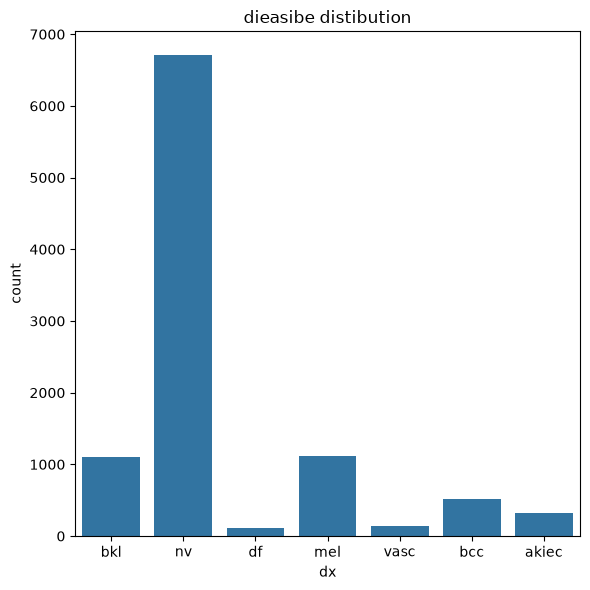

In [13]:
plt.figure(figsize =(6,6))
sns.countplot(data=df,x="dx")
plt.title("dieasibe distibution")
plt.tight_layout()
plt.show()

In [14]:
#the data is imbalenced bcz the dieasise nv hhave around 6500 cases

In [27]:
image_data = []
for i in df['path']:
    image = cv2.imread(i)
    image_data.append({
        "height" : image.shape[0],
        "width" : image.shape[1],
        "channel" : image.shape[2]
    })
    
df_i = pd.DataFrame(image_data)


In [ ]:
df_i["height"].unique()
df_i["width"].unique()
df_i["channel"].unique()

array([3])

In [ ]:
#all the images here are in same dimension

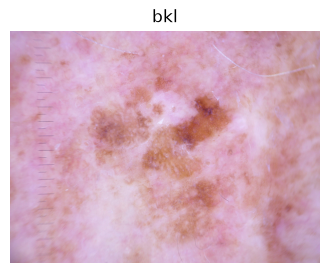

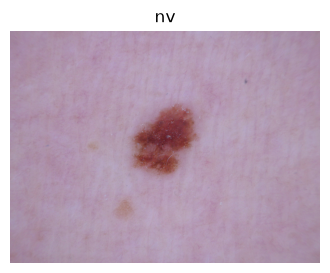

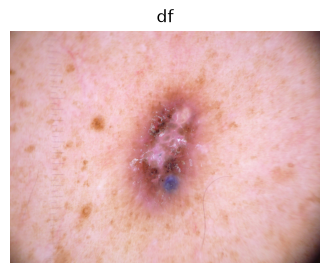

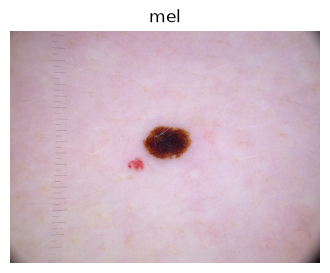

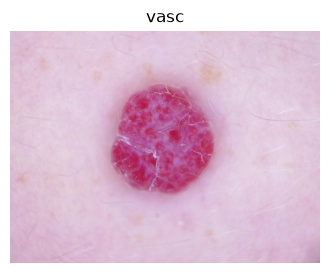

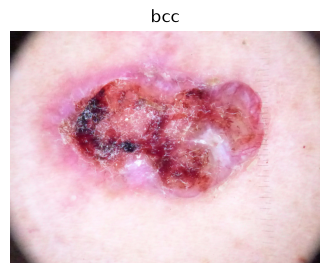

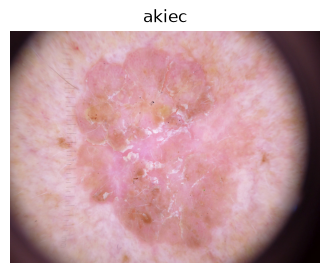

In [35]:
type = df['dx'].unique()

for i in type:
    row = df[df['dx'] == i]
    path = row['path'].iloc[0]
    image = cv2.imread(path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
    plt.figure(figsize=(4, 4))
    plt.imshow(image_rgb)
    plt.title(f"{i}")
    plt.axis('off')
    plt.show() 
    

In [38]:
df_i.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   height   10015 non-null  int64
 1   width    10015 non-null  int64
 2   channel  10015 non-null  int64
dtypes: int64(3)
memory usage: 234.9 KB


In [39]:
df_i.describe()

,height,width,channel
count,10015.0,10015.0,10015.0
mean,450.0,600.0,3.0
std,0.0,0.0,0.0
min,450.0,600.0,3.0
25%,450.0,600.0,3.0
50%,450.0,600.0,3.0
75%,450.0,600.0,3.0
max,450.0,600.0,3.0


In [42]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64

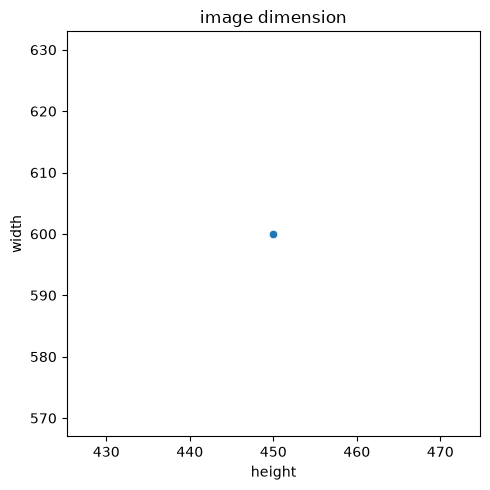

In [48]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df_i,x="height",y="width")
plt.title("image dimension")
plt.xlabel("height")
plt.ylabel("width")
plt.tight_layout()
plt.show()

In [50]:
df['age'] = df['age'].fillna(df["age"].median())

df["age"].isnull().sum()

np.int64(0)

In [51]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
dtype: int64

In [57]:
df.to_csv(r"../data/cleaned/cleaned.csv")


In [53]:
df_train_val, df_test = train_test_split(df, test_size=0.15, 
    random_state=42,stratify=df['dx']  )

val_ratio = 0.15 / 0.85

df_train, df_val = train_test_split(df_train_val, test_size=val_ratio, 
    random_state=42, stratify=df_train_val['dx'] )


In [59]:
df_train

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
8561,HAM_0007001,ISIC_0026573,nv,histo,60.0,female,lower extremity,../data/all_image/ISIC_0026573.jpg
6583,HAM_0006055,ISIC_0031456,nv,follow_up,75.0,female,lower extremity,../data/all_image/ISIC_0031456.jpg
5171,HAM_0006068,ISIC_0024591,nv,follow_up,35.0,male,back,../data/all_image/ISIC_0024591.jpg
3248,HAM_0001590,ISIC_0025722,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0025722.jpg
7903,HAM_0002015,ISIC_0034035,nv,histo,30.0,female,lower extremity,../data/all_image/ISIC_0034035.jpg
...,...,...,...,...,...,...,...,...
7810,HAM_0000639,ISIC_0025257,nv,histo,70.0,female,upper extremity,../data/all_image/ISIC_0025257.jpg
853,HAM_0007043,ISIC_0029947,bkl,consensus,75.0,male,face,../data/all_image/ISIC_0029947.jpg
4257,HAM_0001568,ISIC_0030614,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0030614.jpg
3382,HAM_0005800,ISIC_0028864,nv,follow_up,40.0,female,upper extremity,../data/all_image/ISIC_0028864.jpg


In [60]:
df_test

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
9606,HAM_0000627,ISIC_0034019,nv,consensus,50.0,unknown,unknown,../data/all_image/ISIC_0034019.jpg
5661,HAM_0001761,ISIC_0026732,nv,follow_up,30.0,male,abdomen,../data/all_image/ISIC_0026732.jpg
9355,HAM_0002726,ISIC_0025473,nv,consensus,5.0,male,foot,../data/all_image/ISIC_0025473.jpg
7757,HAM_0003424,ISIC_0033552,nv,histo,45.0,male,back,../data/all_image/ISIC_0033552.jpg
2284,HAM_0004081,ISIC_0031957,mel,histo,70.0,female,lower extremity,../data/all_image/ISIC_0031957.jpg
...,...,...,...,...,...,...,...,...
4063,HAM_0006808,ISIC_0027438,nv,follow_up,65.0,male,lower extremity,../data/all_image/ISIC_0027438.jpg
9437,HAM_0002425,ISIC_0032682,nv,consensus,20.0,male,back,../data/all_image/ISIC_0032682.jpg
6604,HAM_0003747,ISIC_0026582,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0026582.jpg
5841,HAM_0002807,ISIC_0025050,nv,follow_up,45.0,male,trunk,../data/all_image/ISIC_0025050.jpg


In [61]:
df_val

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
8083,HAM_0005421,ISIC_0028060,nv,histo,75.0,male,trunk,../data/all_image/ISIC_0028060.jpg
4277,HAM_0007328,ISIC_0030684,nv,follow_up,50.0,male,lower extremity,../data/all_image/ISIC_0030684.jpg
4773,HAM_0001676,ISIC_0031587,nv,follow_up,60.0,male,upper extremity,../data/all_image/ISIC_0031587.jpg
7783,HAM_0007494,ISIC_0033215,nv,histo,25.0,female,face,../data/all_image/ISIC_0033215.jpg
3011,HAM_0001180,ISIC_0029303,nv,follow_up,50.0,male,trunk,../data/all_image/ISIC_0029303.jpg
...,...,...,...,...,...,...,...,...
7310,HAM_0003507,ISIC_0033459,nv,histo,30.0,male,lower extremity,../data/all_image/ISIC_0033459.jpg
413,HAM_0005514,ISIC_0024453,bkl,histo,65.0,female,face,../data/all_image/ISIC_0024453.jpg
1962,HAM_0001986,ISIC_0024999,mel,histo,50.0,male,upper extremity,../data/all_image/ISIC_0024999.jpg
1053,HAM_0003982,ISIC_0030056,bkl,consensus,50.0,male,trunk,../data/all_image/ISIC_0030056.jpg


In [58]:
df_train.to_csv(r"../data/cleaned/train.csv")
df_test.to_csv(r"../data/cleaned/test.csv")
df_val.to_csv(r"../data/cleaned/val.csv")